## Testing Matched Filter + Connected Component Denoising
This notebook demonstrates the effectiveness of a single-size matched filter implementation on an image of a microcrack.

### About Matched Filter
This matched filter approach is derived from a [technique developed to detect cracks on concrete bridges](https://rdcu.be/fhYiN).

The idea is to use a set of templates abstracting ideal crack shapes in different orientations. In our use case, we have 12 kernels rotated at each step by 15 degrees. The 1D Gaussian projected across each template has a scale (sigma) of 44.

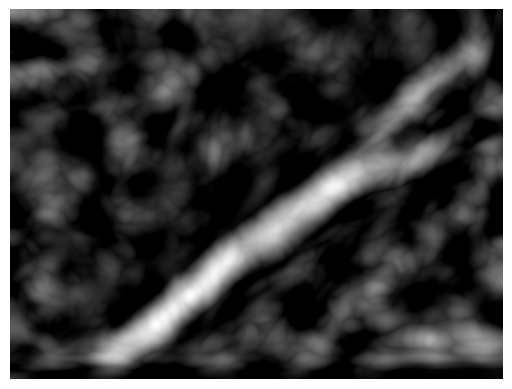

In [278]:
import matched_filter as mf
import matplotlib.pyplot as plt

templates = mf.generate_kernels(sigma=44.0, L=54, angle_step=15)
mask, response = mf.apply_matched_filter_from_path("../images/0098.tif", templates, 0.5)
plt.imshow(response, cmap="gray")
plt.axis('off')
plt.show()

Above shows the **response** of applying the matched filter. Note that because multiple templates are applied, we vote on a pixel by keeping the highest response out of all templates.

This response shows that our generated templates seem to respond best to the crack, but smaller dips in the image still respond when template matching.

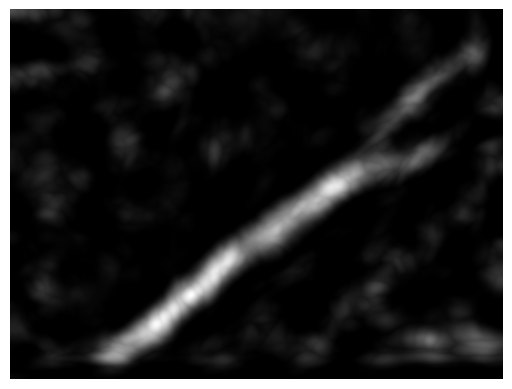

In [279]:
import correction
import cv2

gamma_corrected = correction.apply_gamma_correction(response)
cv2.normalize(gamma_corrected, gamma_corrected, 0.0, 1.0, cv2.NORM_MINMAX)
plt.imshow(gamma_corrected, cmap='gray')
plt.axis('off')
plt.show()

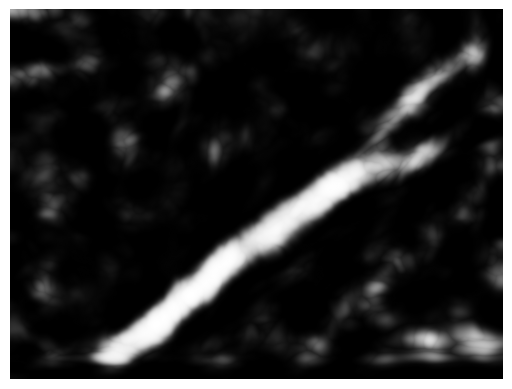

In [280]:
sigmoid_corrected = correction.apply_sigmoid_stretch(response, midpoint=0.5)
cv2.normalize(sigmoid_corrected, sigmoid_corrected, 0.0, 1.0, cv2.NORM_MINMAX)
plt.imshow(sigmoid_corrected, cmap='gray')
plt.axis('off')
plt.show()

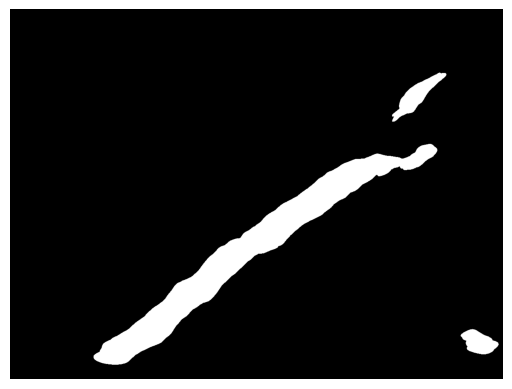

In [281]:
cleaned = mf.ccd(mask, int(mask.size / 500))
plt.imshow(cleaned, cmap='gray')
plt.axis('off')
plt.show()

Instead of using connected component denoising, another technique is to use hysteresis thresholding. Pixels are labeled definitely high or definitely low based on a high threshold and low threshold respectively. Pixels between each are only kept if they are attached to a high pixel.

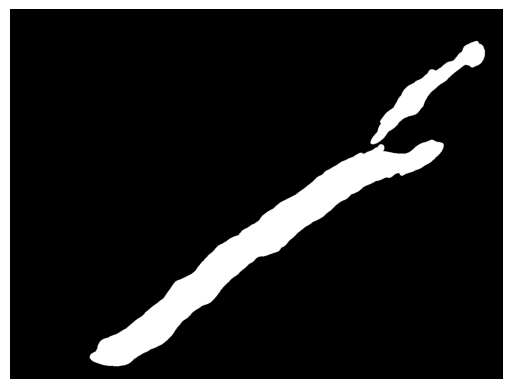

In [282]:
from skimage.filters import apply_hysteresis_threshold
hysteresis_mask = apply_hysteresis_threshold(response, low=0.4, high=0.7)
plt.imshow(hysteresis_mask, cmap='gray')
plt.axis('off')
plt.show()

We can test the effectiveness of the matched filter by calculating the IoU, dice score, and percent error using an annotated image as our ground truth.

In [283]:
import score

img = cv2.imread('../images/annotated/0098.png', cv2.IMREAD_GRAYSCALE)
assert img is not None
ground_truth : cv2.typing.MatLike = img

In [284]:
score.iou(cleaned, ground_truth)

0.652206578568194

In [285]:
score.dice(cleaned, ground_truth)

0.7894976173420126

In [286]:
score.percent_err(cleaned, ground_truth)

0.027500813802083333

In [287]:
score.percent_success(cleaned, ground_truth)

0.9724991861979166

## Binary Mask Results
**Dice score** usually measures something closer to average-case performance while **IoU** measures something closer to worst-case performance. With the parameters above, we get the following:

- Dice score: `78.95%`
- IoU: `65.22%`

However, both weigh pixel errors inversely proportional to the size of the relevant set rather than weighing them equally. This can lead to large penalties on trivial mistakes with small selected ground truths. Therefore, we have also measured percent error:

- Percent error: `2.75%`

Which is the complement of percent success (`97.25%`).

In [288]:
score.iou(hysteresis_mask, ground_truth)

0.7119394739552609

In [289]:
score.dice(hysteresis_mask, ground_truth)

0.8317343980747142

In [290]:
score.percent_err(hysteresis_mask, ground_truth)

0.025035807291666667

## Hysteresis Mask Results
Hysteresis scores higher than binary thresholding with connected component denoising:
- Dice score: `83.17%`
- IoU: `71.19%`
- Percent error: `2.50%`

In [291]:
score.roc_auc(response, ground_truth)

0.9861723076961342

In [292]:
score.pr_auc(response, ground_truth)

0.8710072435518009

## Raw Response - Probabilistic Results
Masking introduces an inherent limitation due to the need to select an appropriate **threshold**. Probabilistic measurements avoid this by scoring the raw response without thresholding; we can thus look at the Receiver-Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) as well as the Precision-Recall (PR) curve and its AUC. Thus, our results come out to be:
- ROC AUC: `98.62%`
- PR AUC: `87.10%`

> Note that PR AUC is a better measurement for performance specifically for our microcrack imaging software because it does not take into account true negatives like ROC AUC. Because there is a "class imbalance" (less positives than negatives or vice versa), ROC AUC will be higher since it factors in these true negatives. PR AUC does not since neither precision nor recall takes into account true negatives.

In [293]:
score.roc_auc(gamma_corrected, ground_truth)

0.9861723076961342

In [294]:
score.pr_auc(gamma_corrected, ground_truth)

0.8710072435518009

In [295]:
score.roc_auc(sigmoid_corrected, ground_truth)

0.9861723076961343

In [296]:
score.pr_auc(sigmoid_corrected, ground_truth)

0.8710072387373079

## Corrected Response - Probabilistic
Although gamma correction and sigmoid stretching appear to respond better to the crack, they don't score higher than the raw response in terms of ROC AUC and PR AUC. The reason I introduce gamma correction and sigmoid stretching is mainly for masking later on.